# Volleyball Match Outcome Prediction using Machine Learning

## Project Overview

This project aims to predict volleyball match outcomes by using team performance statistics and machine learning algorithms. The dataset includes several offensive and defensive performance metrics, such as aces, assists, attacks, blocks, digs, hitting percentage, kills, and opponent hitting percentage. By analyzing these features, the project compares different machine learning models to determine how well team statistics can be used to predict successful performance.

## Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## Loading the Dataset

In [2]:
possible_paths = [
    Path("volleyball_matches.csv"),
    Path.home() / "Downloads" / "anaconda_projects_20976931-7599-4a32-98b5-0c5c9325b095_volleyball_matches.csv"
]

data_path = next((path for path in possible_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError("Dataset file was not found. Please place volleyball_matches.csv in the notebook folder.")

df = pd.read_csv(data_path)
print("Dataset shape:", df.shape)

Dataset shape: (334, 14)


## Displaying the First Rows of the Dataset

In [3]:
df.head()

,Team,Conference,region,aces_per_set,assists_per_set,team_attacks_per_set,blocks_per_set,digs_per_set,hitting_pctg,kills_per_set,opp_hitting_pctg,W,L,win_loss_pctg
0,Lafayette,Patriot,East,2.33,11.01,34.54,1.31,13.60,0.180,11.93,0.227,8,15,0.348
1,Delaware St.,MEAC,Southeast,2.20,11.45,29.98,2.17,12.58,0.250,12.12,0.137,24,7,0.774
2,Yale,Ivy League,East,2.15,12.60,35.39,1.82,15.29,0.242,13.90,0.155,23,3,0.885
3,Coppin St.,MEAC,Southeast,2.15,10.56,32.52,1.81,14.22,0.194,11.54,0.170,23,11,0.676
4,Saint Louis,Atlantic 10,East,2.03,11.61,34.10,1.83,14.27,0.201,12.40,0.188,18,13,0.581


## Column Names

In [4]:
df.columns

Index(['Team', 'Conference', 'region', 'aces_per_set', 'assists_per_set',
       'team_attacks_per_set', 'blocks_per_set', 'digs_per_set',
       'hitting_pctg', 'kills_per_set', 'opp_hitting_pctg', 'W', 'L',
       'win_loss_pctg'],
      dtype='object')

## Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Team                  334 non-null    object 
 1   Conference            333 non-null    object 
 2   region                334 non-null    object 
 3   aces_per_set          334 non-null    float64
 4   assists_per_set       334 non-null    float64
 5   team_attacks_per_set  334 non-null    float64
 6   blocks_per_set        334 non-null    float64
 7   digs_per_set          334 non-null    float64
 8   hitting_pctg          332 non-null    float64
 9   kills_per_set         334 non-null    float64
 10  opp_hitting_pctg      334 non-null    float64
 11  W                     334 non-null    int64  
 12  L                     334 non-null    int64  
 13  win_loss_pctg         334 non-null    float64
dtypes: float64(9), int64(2), object(3)
memory usage: 36.7+ KB


## Statistical Summary

In [6]:
df.describe()

,aces_per_set,assists_per_set,team_attacks_per_set,blocks_per_set,digs_per_set,hitting_pctg,kills_per_set,opp_hitting_pctg,W,L,win_loss_pctg
count,334.000000,334.000000,334.000000,334.000000,334.000000,332.000000,334.000000,334.000000,334.000000,334.000000,334.000000
mean,1.465359,11.431617,34.457066,2.057365,14.352096,0.207864,12.365329,0.207596,15.134731,14.718563,0.499587
std,0.233186,1.196959,1.940032,0.381777,1.465299,0.040492,1.243664,0.028662,6.594414,5.536541,0.199268
min,0.900000,4.440000,24.250000,0.600000,7.420000,0.079000,4.920000,0.128000,0.000000,1.000000,0.000000
25%,1.310000,10.872500,33.352500,1.810000,13.330000,0.183000,11.780000,0.187000,10.000000,11.000000,0.345000
50%,1.455000,11.540000,34.470000,2.070000,14.325000,0.208000,12.460000,0.205500,15.000000,15.000000,0.515500
75%,1.610000,12.137500,35.885000,2.300000,15.350000,0.233000,13.137500,0.227000,19.000000,19.000000,0.635250
max,2.330000,13.800000,39.780000,3.330000,18.530000,0.336000,14.750000,0.338000,31.000000,31.000000,0.966000


## Checking Missing Values

In [8]:
df.isnull().sum()

Team                    0
Conference              1
region                  0
aces_per_set            0
assists_per_set         0
team_attacks_per_set    0
blocks_per_set          0
digs_per_set            0
hitting_pctg            2
kills_per_set           0
opp_hitting_pctg        0
W                       0
L                       0
win_loss_pctg           0
dtype: int64

## Data Quality Analysis

In [10]:
missing_summary = df.isna().sum().sort_values(ascending=False)

print("Total rows:", len(df))
print("Total columns:", len(df.columns))

print("\nMissing Values:")
print(missing_summary[missing_summary > 0])

Total rows: 334
Total columns: 14

Missing Values:
hitting_pctg    2
Conference      1
dtype: int64


## Exploratory Data Analysis (EDA)

In this section, we explore the dataset using visualizations and statistical analysis to better understand the relationships between different variables.

## Distribution of Key Features

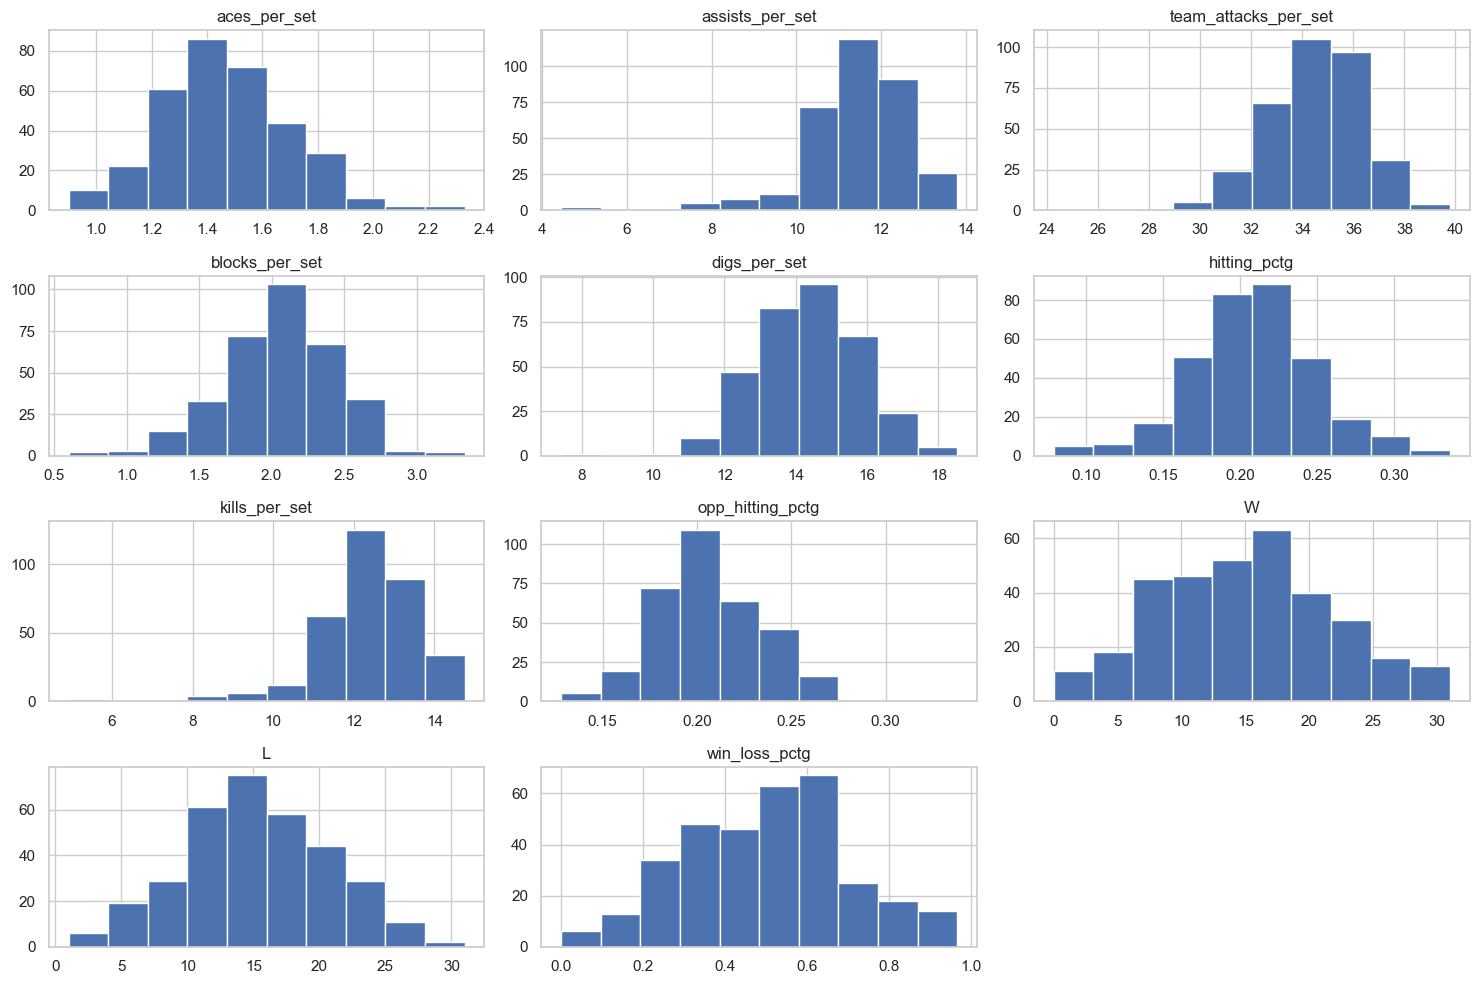

In [11]:
numeric_features = df.select_dtypes(include=['float64', 'int64']).columns

df[numeric_features].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

## Correlation Matrix

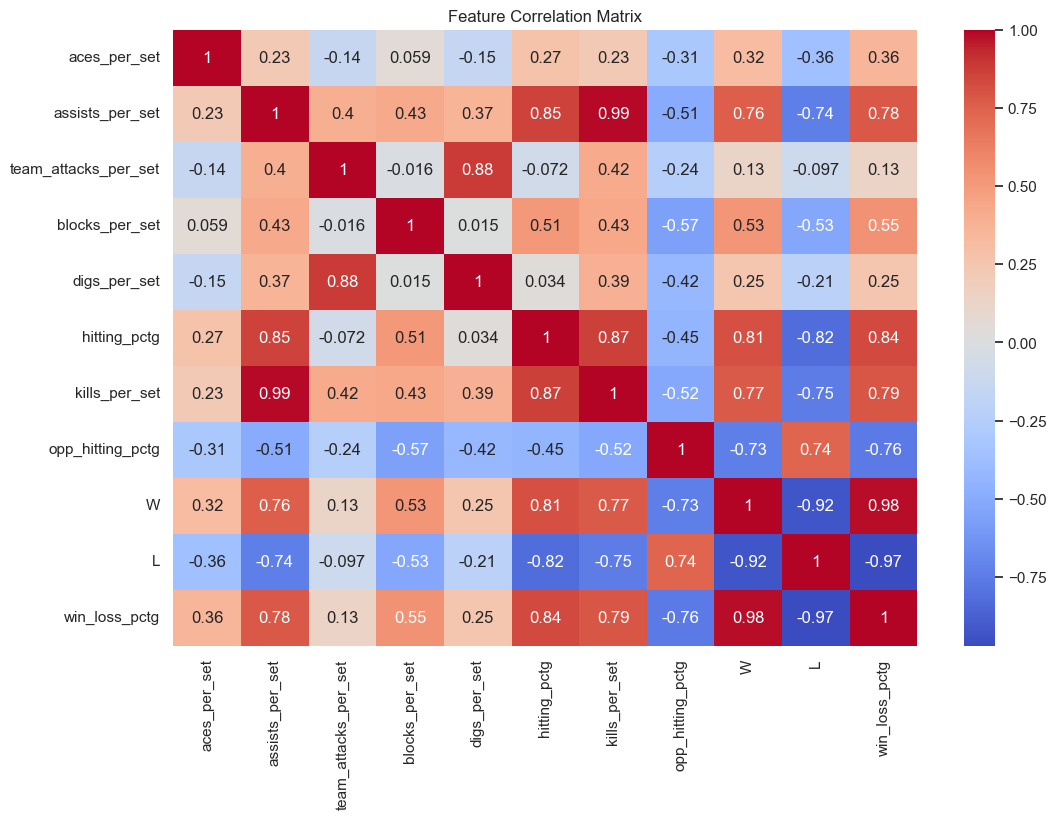

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

## Creating Target Variable

In [13]:
df["target"] = (df["win_loss_pctg"] > 0.5).astype(int)

df[["win_loss_pctg","target"]].head()

,win_loss_pctg,target
0,0.348,0
1,0.774,1
2,0.885,1
3,0.676,1
4,0.581,1


## Relationship Between Important Features

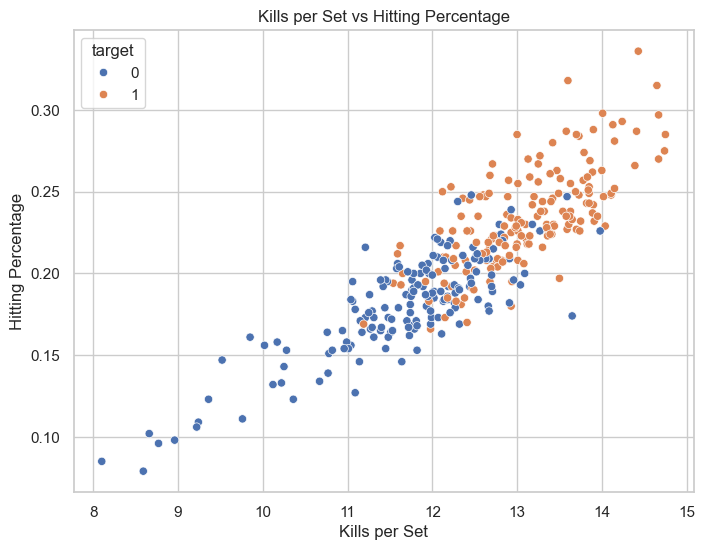

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="kills_per_set", y="hitting_pctg", hue="target", data=df)

plt.title("Kills per Set vs Hitting Percentage")
plt.xlabel("Kills per Set")
plt.ylabel("Hitting Percentage")
plt.show()

## Win and Loss Distribution

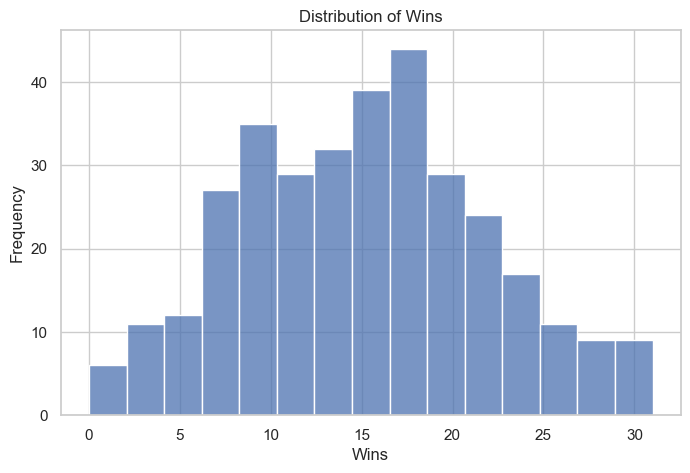

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["W"], bins=15)
plt.title("Distribution of Wins")
plt.xlabel("Wins")
plt.ylabel("Frequency")
plt.show()

To predict match outcomes, we create a binary target variable based on the win-loss percentage.
Teams with a win-loss percentage greater than 0.50 are labeled as 1, otherwise 0.

## Target Variable Distribution

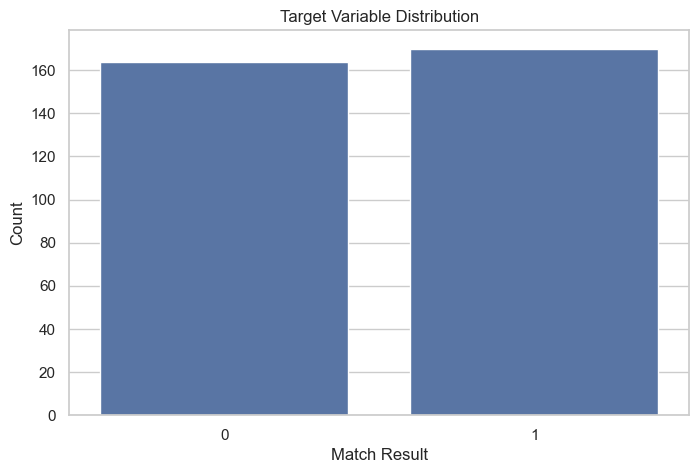

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(x=df["target"])

plt.title("Target Variable Distribution")
plt.xlabel("Match Result")
plt.ylabel("Count")

plt.show()

## Feature Selection

In [17]:
features = [
    "aces_per_set",
    "assists_per_set",
    "team_attacks_per_set",
    "blocks_per_set",
    "digs_per_set",
    "hitting_pctg",
    "kills_per_set",
    "opp_hitting_pctg"
]

X = df[features]
y = df["target"]

print("Total number of rows used for modelling:", X.shape[0])
print("Number of features:", X.shape[1])
print("Rows with missing feature values:", X.isnull().any(axis=1).sum())

Total number of rows used for modelling: 334
Number of features: 8
Rows with missing feature values: 2


## Preventing Data Leakage

### Why were `W`, `L`, and `win_loss_pctg` excluded?

These variables were excluded to prevent data leakage.

Since `win_loss_pctg` directly reflects match success, using it as an input feature would indirectly expose the target variable to the model.

Similarly, `W` (wins) and `L` (losses) are strongly outcome-related variables that could artificially inflate model accuracy.

## Splitting the Dataset into Training and Testing Sets

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Train target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("Test target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Train size: (267, 8)
Test size: (67, 8)
Train target distribution:
target
1    0.509
0    0.491
Name: proportion, dtype: float64
Test target distribution:
target
1    0.507
0    0.493
Name: proportion, dtype: float64


## Data Preprocessing Pipeline

In [19]:
numeric_preprocess_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_preprocess_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])


## Model Training 


### Random Forest

In [20]:
model = Pipeline([
    ("preprocess", numeric_preprocess_tree),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

model.fit(X_train, y_train)

y_pred_rf = model.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_acc)


Random Forest Accuracy: 0.9253731343283582


### Logistic Regression

In [21]:
log_model = Pipeline([
    ("preprocess", numeric_preprocess_scaled),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
log_acc = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_acc)


Logistic Regression Accuracy: 0.9552238805970149


### Gradient Boosting

In [22]:
gb_model = Pipeline([
    ("preprocess", numeric_preprocess_tree),
    ("classifier", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
gb_acc = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", gb_acc)


Gradient Boosting Accuracy: 0.9402985074626866


## Cross Validation

In [23]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

rf_scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

log_scores = cross_val_score(
    log_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

gb_scores = cross_val_score(
    gb_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

cv_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Logistic Regression",
        "Gradient Boosting"
    ],
    "CV Accuracy Mean": [
        rf_scores.mean(),
        log_scores.mean(),
        gb_scores.mean()
    ],
    "CV Accuracy Std": [
        rf_scores.std(),
        log_scores.std(),
        gb_scores.std()
    ]
})

cv_results


,Model,CV Accuracy Mean,CV Accuracy Std
0,Random Forest,0.892175,0.017667
1,Logistic Regression,0.904206,0.007108
2,Gradient Boosting,0.874220,0.040809


## Model Evaluation

In [24]:
y_pred = y_pred_rf
accuracy = rf_acc

print("Random Forest Accuracy:", accuracy)

Random Forest Accuracy: 0.9253731343283582


## Baseline Accuracy

In [25]:
baseline_accuracy = y.value_counts(normalize=True).max()
print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.5089820359281437


## Accuracy Comparison

In [26]:
comparison = pd.DataFrame({
    "Metric": [
        "Baseline Accuracy",
        "Random Forest",
        "Logistic Regression",
        "Gradient Boosting"
    ],
    "Score": [
        baseline_accuracy,
        rf_acc,
        log_acc,
        gb_acc
    ]
})

comparison

,Metric,Score
0,Baseline Accuracy,0.508982
1,Random Forest,0.925373
2,Logistic Regression,0.955224
3,Gradient Boosting,0.940299


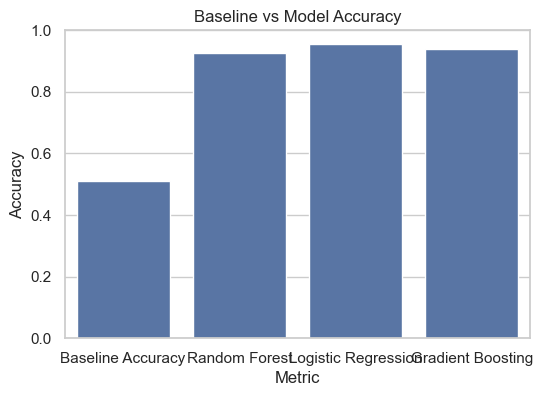

In [27]:
plt.figure(figsize=(6,4))
sns.barplot(data=comparison, x="Metric", y="Score")

plt.title("Baseline vs Model Accuracy")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.show()

## Confusion Matrix

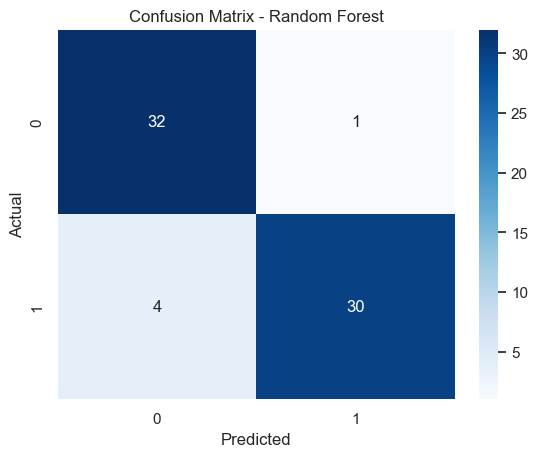

In [28]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Classification Report

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.97      0.93        33
           1       0.97      0.88      0.92        34

    accuracy                           0.93        67
   macro avg       0.93      0.93      0.93        67
weighted avg       0.93      0.93      0.93        67



## Feature Importance

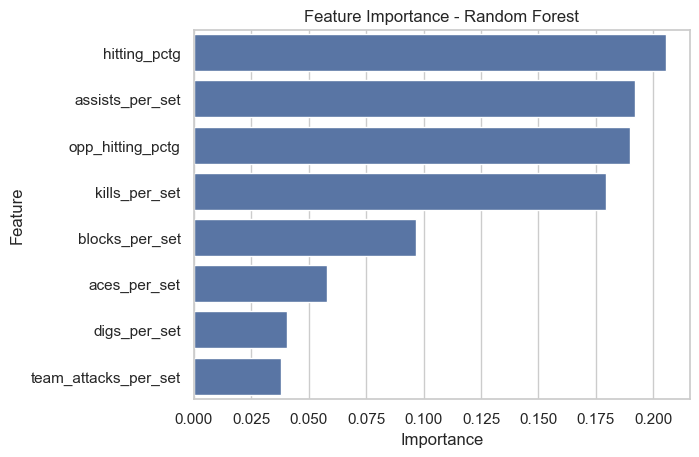

In [30]:
importance = model.named_steps["classifier"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

sns.barplot(x="Importance", y="Feature", data=feature_importance)
plt.title("Feature Importance - Random Forest")
plt.show()


## Conclusion

In this project, machine learning models were developed to predict volleyball match outcomes using team performance statistics. Key offensive and defensive metrics, including aces, assists, attacks, blocks, digs, hitting percentage, kills per set, and opponent hitting percentage, were used as input features.

Three different models, Random Forest, Logistic Regression, and Gradient Boosting, were trained and compared to evaluate their predictive performance. The results were also compared with the baseline accuracy to determine whether the models performed better than a simple majority-class prediction.

The comparison showed that the machine learning models achieved higher accuracy than the baseline model. In addition, the feature importance analysis helped identify which volleyball performance metrics had the strongest influence on the prediction results.

## Saving the Trained Model

In [ ]:
import joblib

joblib.dump(model, "volleyball_model.pkl")